#Projeto A3
## Fase 2: Limpeza e Transformação de Dados
**Dataset:** Spotify Tracks — 114.000 músicas  
**Problema:** *"O que faz uma música ser popular? É possível prever a popularidade?"*

---
### Estrutura do Notebook
| Seção | Descrição |
|---|---|
| 0 | Instalação e Carregamento |
| 1 | Inspeção Inicial |
| 2 | Valores Ausentes (Nulls) |
| 3 | Remoção de Duplicatas |
| 4 | Correção de Tipos de Dados |
| 5 | Detecção e Tratamento de Outliers |
| 6 | Codificação de Variáveis Categóricas |
| 7 | Normalização |
| 8 | Divisão Treino/Teste |
| 9 | Análise Exploratória (EDA) |
| 10 | Salvando os Datasets Finais |

---
## 0. Instalação de Bibliotecas e Carregamento dos Dados
Importamos as bibliotecas necessárias para manipulação de dados, visualização e machine learning.  
Em seguida, fazemos o upload do arquivo CSV diretamente no Google Colab.

In [ ]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


In [ ]:
# Montando o Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Carregamento do dataset direto da pasta A3 2026
df = pd.read_csv('/content/drive/MyDrive/A3 2026/dataset.csv')

print(f'✅ Dataset carregado com sucesso!')
print(f'   Shape: {df.shape[0]} linhas x {df.shape[1]} colunas')

Mounted at /content/drive
✅ Dataset carregado com sucesso!
   Shape: 114000 linhas x 21 colunas


---
## 1. Inspeção Inicial
Antes de qualquer limpeza, é fundamental entender o que temos:  
quantas linhas, quais colunas, quais tipos de dados e como os valores estão distribuídos.  

Esta etapa é a base para todas as decisões de limpeza que serão tomadas a seguir.

In [ ]:
print('=== TIPOS DE DADOS ===')
print(df.dtypes)
print(f'\nShape original: {df.shape}')

=== TIPOS DE DADOS ===
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Shape original: (114000, 21)


In [ ]:
print('=== PRIMEIRAS 5 LINHAS ===')
df.head()

=== PRIMEIRAS 5 LINHAS ===


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
print('=== ESTATÍSTICAS DESCRITIVAS ===')
df.describe()

=== ESTATÍSTICAS DESCRITIVAS ===


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


---
## 2. Valores Ausentes (Nulls)
Dados reais frequentemente possuem valores faltantes. Identificamos abaixo quais colunas possuem nulos e qual percentual representam.

### Decisões tomadas:
- **Colunas críticas** (`track_name`, `artists`, `track_genre`, `popularity`): linhas com nulos são **removidas**, pois sem esses campos o registro não tem valor analítico.
- **Colunas numéricas** com nulos: preenchidas com a **mediana**, pois ela é mais robusta que a média e não é distorcida por valores extremos.

In [ ]:
# Visualizando os valores nulos
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_report = pd.DataFrame({'Nulos': nulls, 'Percentual (%)': nulls_pct})

print('Colunas com valores ausentes:')
print(null_report[null_report['Nulos'] > 0])

if null_report['Nulos'].sum() == 0:
    print('✅ Nenhum valor ausente encontrado nesta amostra.')

Colunas com valores ausentes:
            Nulos  Percentual (%)
artists         1             0.0
album_name      1             0.0
track_name      1             0.0


In [ ]:
# Removendo linhas com nulos em colunas críticas
colunas_criticas = ['track_name', 'artists', 'track_genre', 'popularity']
antes = len(df)
df = df.dropna(subset=colunas_criticas)
print(f'✅ Linhas removidas por nulos em colunas críticas: {antes - len(df)}')

# Imputando nulos em colunas numéricas com a mediana
colunas_numericas = ['danceability', 'energy', 'loudness', 'speechiness',
                     'acousticness', 'instrumentalness', 'liveness',
                     'valence', 'tempo', 'duration_ms']

for col in colunas_numericas:
    qtd_nulos = df[col].isnull().sum()
    if qtd_nulos > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)
        print(f'✅ {col}: {qtd_nulos} nulos preenchidos com mediana ({mediana:.4f})')

print(f'\nShape após tratamento de nulos: {df.shape}')

✅ Linhas removidas por nulos em colunas críticas: 1

Shape após tratamento de nulos: (113999, 21)


---
## 3. Remoção de Duplicatas
O dataset do Spotify apresenta um problema comum: a **mesma música aparece em múltiplas playlists** com `track_id` diferentes, mas com conteúdo sonoro idêntico.

**Exemplo identificado na análise:** *"Winter Wonderland"* de Jason Mraz aparece em 8 playlists diferentes ("Christmas Music", "Lonely Christmas 2022", "Merry Christmas", etc.) com o mesmo áudio.

### Decisões tomadas:
- **Duplicatas por `track_id`**: removidas, mantendo a primeira ocorrência.
- **Mesma música em múltiplos álbuns/playlists** (`track_name` + `artists`): mantida apenas a versão com **maior popularidade**, pois representa o registro mais relevante para o modelo.

In [ ]:
# Verificando duplicatas
dup_track_id = df.duplicated(subset=['track_id']).sum()
dup_musica   = df.duplicated(subset=['track_name', 'artists'], keep=False).sum()

print(f'Duplicatas por track_id (exatas):              {dup_track_id}')
print(f'Músicas repetidas em álbuns/playlists difer.:  {dup_musica}')

# Exemplos de duplicatas por playlist
print('\nExemplo — mesma música em playlists diferentes:')
exemplo = df[df.duplicated(subset=['track_name', 'artists'], keep=False)]
exemplo[['track_name', 'artists', 'album_name', 'popularity']].head(8)

Duplicatas por track_id (exatas):              24259
Músicas repetidas em álbuns/playlists difer.:  49157

Exemplo — mesma música em playlists diferentes:


,track_name,artists,album_name,popularity
0,Comedy,Gen Hoshino,Comedy,73
1,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),55
3,Can't Help Falling In Love,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,71
4,Hold On,Chord Overstreet,Hold On,82
5,Days I Will Remember,Tyrone Wells,Days I Will Remember,58
6,Say Something,A Great Big World;Christina Aguilera,Is There Anybody Out There?,74
7,I'm Yours,Jason Mraz,We Sing. We Dance. We Steal Things.,80
8,Lucky,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,74


In [ ]:
# Removendo duplicatas por track_id
antes = len(df)
df = df.drop_duplicates(subset=['track_id'], keep='first')
print(f'✅ Removidas {antes - len(df)} duplicatas exatas por track_id')

# Removendo músicas repetidas em múltiplos álbuns (mantendo maior popularidade)
antes = len(df)
df = df.sort_values('popularity', ascending=False)
df = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')
print(f'✅ Removidas {antes - len(df)} músicas duplicadas em álbuns/playlists')
print(f'   (mantida a versão com maior popularidade para cada música única)')

print(f'\nShape após remoção de duplicatas: {df.shape}')

✅ Removidas 24259 duplicatas exatas por track_id
✅ Removidas 8397 músicas duplicadas em álbuns/playlists
   (mantida a versão com maior popularidade para cada música única)

Shape após remoção de duplicatas: (81343, 21)


---
## 4. Correção de Tipos de Dados
Alguns campos possuem tipos incorretos que podem causar erros nos algoritmos de machine learning.

### Problemas identificados:
- **`explicit`**: pode ser lida como string `"TRUE"/"FALSE"` dependendo do sistema. Deve ser convertida para inteiro `0/1`.
- **`duration_ms`**: duração em milissegundos é pouco interpretável. Convertemos para **minutos** e removemos a coluna original.

In [ ]:
# Corrigindo tipo da coluna 'explicit'
if df['explicit'].dtype == object:
    df['explicit'] = df['explicit'].map({'TRUE': True, 'FALSE': False,
                                          True: True, False: False})
    print('✅ explicit convertida de string para booleano')

df['explicit'] = df['explicit'].astype(int)
print(f'✅ explicit convertida para inteiro (0/1)')
print(f'   Distribuição: {df["explicit"].value_counts().to_dict()}')

# Convertendo duration_ms para minutos
df['duration_min'] = (df['duration_ms'] / 60000).round(2)
df = df.drop(columns=['duration_ms'])
print(f'\n✅ duration_ms → duration_min (minutos)')
print(f'   Duração média: {df["duration_min"].mean():.2f} minutos')
print(f'   Min: {df["duration_min"].min():.2f} | Max: {df["duration_min"].max():.2f}')

✅ explicit convertida para inteiro (0/1)
   Distribuição: {0: 74382, 1: 6961}

✅ duration_ms → duration_min (minutos)
   Duração média: 3.86 minutos
   Min: 0.14 | Max: 87.29


---
## 5. Detecção e Tratamento de Outliers
Outliers são valores atípicos que podem distorcer os algoritmos de machine learning.  
Usamos o método **IQR (Intervalo Interquartílico)** para identificá-los visualmente via boxplots.

### Decisões tomadas por variável:
| Variável | Decisão | Justificativa |
|---|---|---|
| `popularity = 0` | **Mantido** | Representa músicas reais sem reproduções suficientes para ranqueamento |
| `duration_min < 0.5` ou `> 15` | **Removido** | Provavelmente interlúdios, podcasts ou erros de catalogação |
| `loudness` extremo | **Mantido** | Representa variação legítima entre gêneros (clássico vs. metal) |
| `liveness > 0.8` | **Mantido** | Representa músicas ao vivo, um subgênero válido |

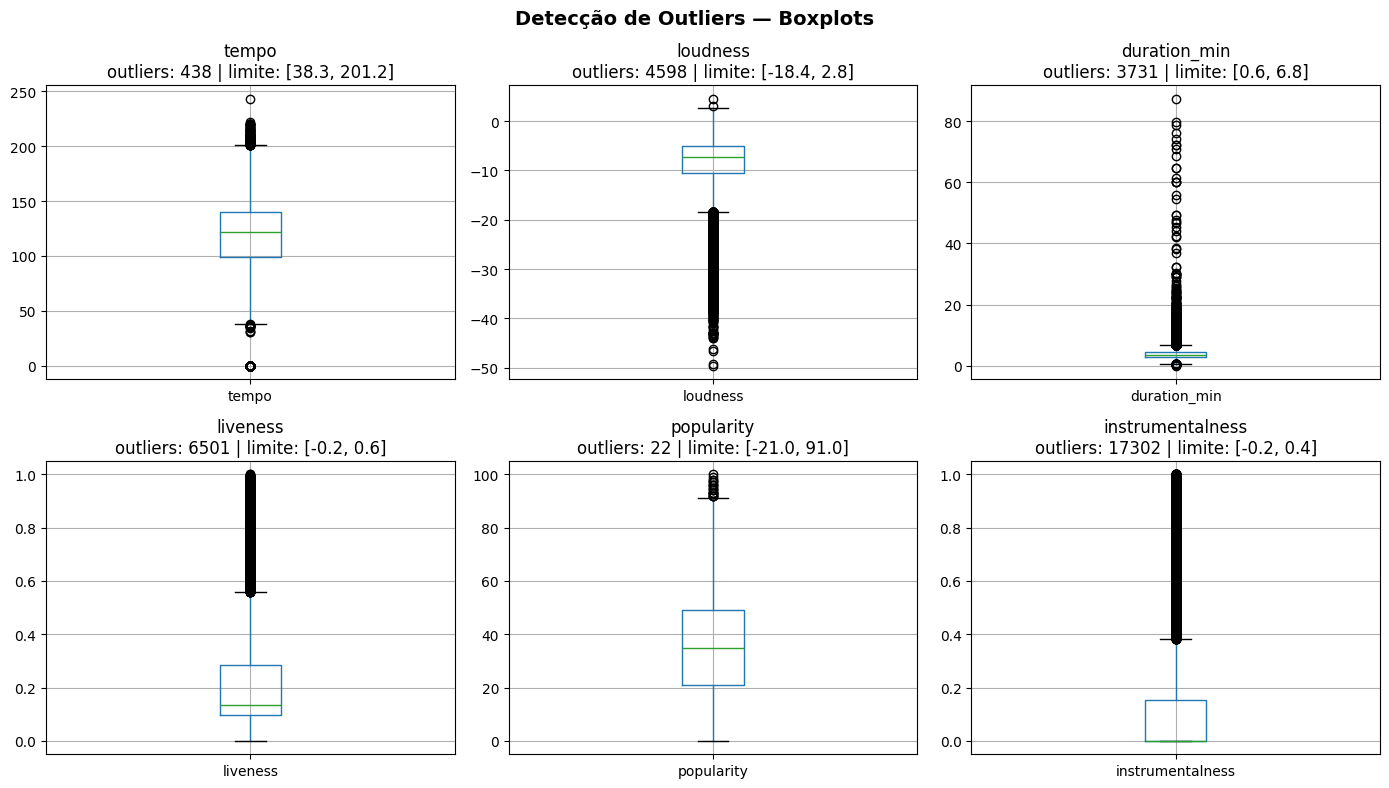

✅ Boxplots gerados e salvos.


In [ ]:
# Visualizando outliers com boxplots
colunas_outlier = ['tempo', 'loudness', 'duration_min', 'liveness', 'popularity', 'instrumentalness']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Detecção de Outliers — Boxplots', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), colunas_outlier):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    df.boxplot(column=col, ax=ax)
    ax.set_title(f'{col}\noutliers: {outliers} | limite: [{lower:.1f}, {upper:.1f}]')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Boxplots gerados e salvos.')

In [ ]:
# Removendo músicas com duração fora do intervalo razoável
antes = len(df)
df = df[(df['duration_min'] >= 0.5) & (df['duration_min'] <= 15)]
print(f'✅ Removidas {antes - len(df)} músicas com duração fora de [0.5, 15] minutos')

# Informativo sobre popularidade = 0
pop_zero = (df['popularity'] == 0).sum()
print(f'\nMúsicas com popularidade = 0: {pop_zero} ({pop_zero/len(df)*100:.1f}%)')
print('➡️  Mantidas: representam o extremo inferior real da popularidade.')

print(f'\nShape após tratamento de outliers: {df.shape}')

✅ Removidas 152 músicas com duração fora de [0.5, 15] minutos

Músicas com popularidade = 0: 4771 (5.9%)
➡️  Mantidas: representam o extremo inferior real da popularidade.

Shape após tratamento de outliers: (81191, 21)


---
## 6. Codificação de Variáveis Categóricas (Encoding)
Algoritmos de machine learning trabalham com números, não com texto.  
Precisamos converter as variáveis categóricas para formato numérico.

### Decisões tomadas:
- **`track_genre`** → **Label Encoding** (um número para cada gênero).  
  *Por que não One-Hot Encoding?* O dataset tem 114 gêneros distintos. One-Hot criaria 114 colunas novas, tornando o dataset esparso demais para os algoritmos.

- **`popularity`** → Criada nova coluna `popularity_category` com 4 faixas:  
  `0–25: Obscura` | `26–50: Em Ascensão` | `51–75: Mainstream` | `76–100: Hit`  
  Essa categorização será usada como variável-alvo no algoritmo de **Árvore de Decisão**.

In [ ]:
# Label Encoding para track_genre
le = LabelEncoder()
df['track_genre_encoded'] = le.fit_transform(df['track_genre'])

print(f'✅ track_genre codificada com Label Encoding')
print(f'   Total de gêneros únicos: {df["track_genre"].nunique()}')
print(f'\nPrimeiros 5 mapeamentos:')
for genero, codigo in zip(le.classes_[:5], le.transform(le.classes_[:5])):
    print(f'   {genero} → {codigo}')

# Salvando o mapeamento completo
genre_mapping = pd.DataFrame({'genero': le.classes_, 'codigo': le.transform(le.classes_)})
genre_mapping.to_csv('genre_mapping.csv', index=False)
print('\n✅ Mapeamento completo salvo em genre_mapping.csv')

✅ track_genre codificada com Label Encoding
   Total de gêneros únicos: 113

Primeiros 5 mapeamentos:
   acoustic → 0
   afrobeat → 1
   alt-rock → 2
   alternative → 3
   ambient → 4

✅ Mapeamento completo salvo em genre_mapping.csv


In [ ]:
# Criando variável de popularidade categorizada
df['popularity_category'] = pd.cut(
    df['popularity'],
    bins=[-1, 25, 50, 75, 100],
    labels=['Obscura', 'Em Ascensão', 'Mainstream', 'Hit']
)
df['popularity_category_encoded'] = pd.cut(
    df['popularity'],
    bins=[-1, 25, 50, 75, 100],
    labels=[0, 1, 2, 3]
).astype(int)

print('✅ Coluna popularity_category criada:')
print(df['popularity_category'].value_counts().sort_index())

✅ Coluna popularity_category criada:
popularity_category
Obscura        28367
Em Ascensão    33711
Mainstream     17870
Hit             1243
Name: count, dtype: int64


---
## 7. Normalização / Escalonamento (Min-Max Scaling)
Variáveis em escalas muito diferentes podem fazer com que o algoritmo dê peso desproporcional para certas features.

**Exemplo:** `loudness` varia de -60 a 0 dB, enquanto `danceability` varia de 0 a 1.  
Sem normalização, o algoritmo pode interpretar `loudness` como mais importante só pela magnitude.

### Decisões tomadas:
- **Colunas que já estão em [0,1]** (`danceability`, `energy`, `valence`, etc.): **não precisam** de normalização.
- **Colunas fora dessa escala** (`loudness`, `tempo`, `duration_min`, `popularity`): aplicamos **Min-Max Scaling**, que transforma todos os valores para o intervalo [0, 1].

In [ ]:
# Aplicando Min-Max Scaling
colunas_para_normalizar = ['loudness', 'tempo', 'duration_min', 'popularity']

scaler = MinMaxScaler()
df_normalizado = df.copy()
df_normalizado[colunas_para_normalizar] = scaler.fit_transform(df[colunas_para_normalizar])

print(f'✅ Min-Max Scaling aplicado em: {colunas_para_normalizar}')
print('\nVerificação — todos os valores devem estar entre 0 e 1:')
df_normalizado[colunas_para_normalizar].describe().loc[['min', 'max']]

✅ Min-Max Scaling aplicado em: ['loudness', 'tempo', 'duration_min', 'popularity']

Verificação — todos os valores devem estar entre 0 e 1:


,loudness,tempo,duration_min,popularity
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


---
## 8. Divisão Treino / Teste (80% / 20%)
Separamos o dataset em dois conjuntos:
- **Treino (80%)**: usado para os algoritmos **aprenderem** os padrões.
- **Teste (20%)**: usado para **avaliar** o desempenho dos modelos em dados nunca vistos.

Definimos `random_state=42` para garantir **reprodutibilidade** — toda vez que o código rodar, a divisão será a mesma.

### Features e Targets definidos por algoritmo:
| Algoritmo | Tipo | Target |
|---|---|---|
| K-Means Clustering | Não supervisionado | Sem target |
| Árvore de Decisão | Classificação | `popularity_category` (0–3) |
| Regressão Linear | Regressão | `popularity` (0–100) |

In [ ]:
# Definindo features e targets
FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_min', 'explicit', 'key', 'mode',
    'time_signature', 'track_genre_encoded'
]

TARGET_REGRESSAO     = 'popularity'                   # Regressão Linear
TARGET_CLASSIFICACAO = 'popularity_category_encoded'  # Árvore de Decisão
# K-Means não usa target (não supervisionado)

X      = df_normalizado[FEATURES]
y_reg  = df_normalizado[TARGET_REGRESSAO]
y_clf  = df_normalizado[TARGET_CLASSIFICACAO]

# Divisão 80/20
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

print(f'✅ Divisão realizada com sucesso!')
print(f'   Features: {len(FEATURES)} colunas')
print(f'   Treino:   {X_train.shape[0]} amostras ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'   Teste:    {X_test.shape[0]} amostras ({X_test.shape[0]/len(df)*100:.0f}%)')

✅ Divisão realizada com sucesso!
   Features: 15 colunas
   Treino:   64952 amostras (80%)
   Teste:    16239 amostras (20%)


---
## 9. Análise Exploratória de Dados (EDA)
A EDA nos permite **visualizar padrões, correlações e distribuições** antes de aplicar os algoritmos.
Essa etapa é essencial para validar as decisões de limpeza e entender melhor o problema.

### Visualizações geradas:
1. Distribuição de popularidade
2. Danceability vs. Popularidade
3. Top 10 gêneros mais presentes
4. Mapa de correlação entre features
5. Distribuição por categoria de popularidade
6. Energy vs. Valence (colorido por popularidade)

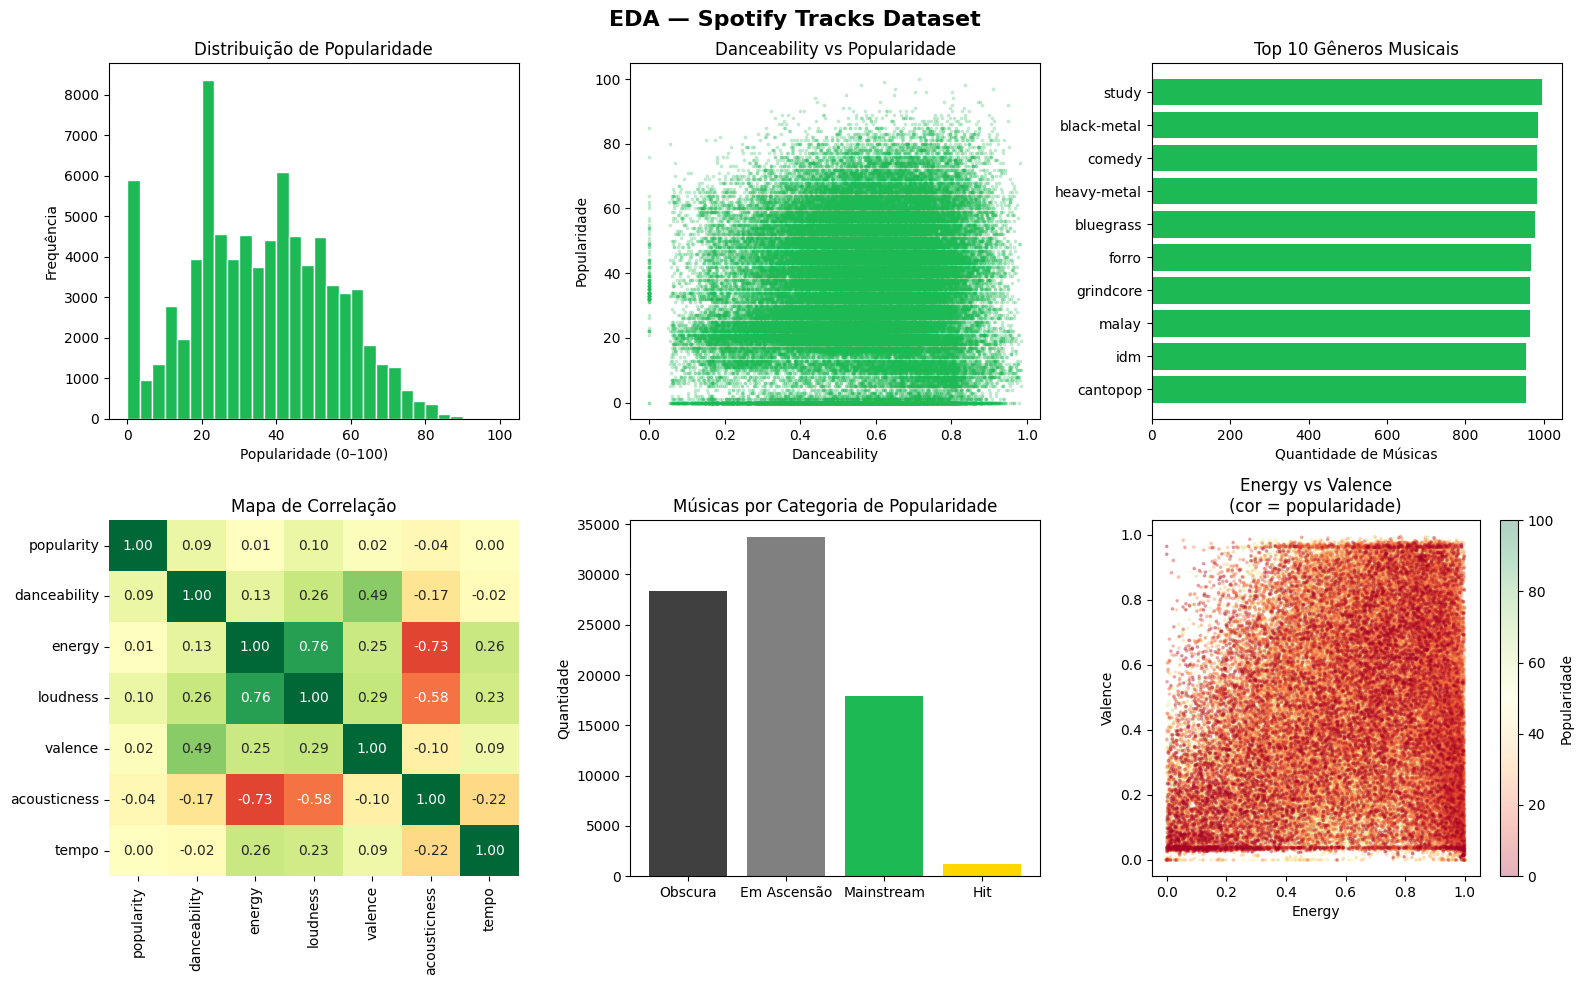

✅ EDA salvo em eda_spotify.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Spotify Tracks Dataset', fontsize=16, fontweight='bold')

# 1. Distribuição de popularidade
axes[0,0].hist(df['popularity'], bins=30, color='#1DB954', edgecolor='white')
axes[0,0].set_title('Distribuição de Popularidade')
axes[0,0].set_xlabel('Popularidade (0–100)')
axes[0,0].set_ylabel('Frequência')

# 2. Danceability vs Popularidade
axes[0,1].scatter(df['danceability'], df['popularity'], alpha=0.2, color='#1DB954', s=3)
axes[0,1].set_title('Danceability vs Popularidade')
axes[0,1].set_xlabel('Danceability')
axes[0,1].set_ylabel('Popularidade')

# 3. Top 10 gêneros
top_generos = df['track_genre'].value_counts().head(10)
axes[0,2].barh(top_generos.index[::-1], top_generos.values[::-1], color='#1DB954')
axes[0,2].set_title('Top 10 Gêneros Musicais')
axes[0,2].set_xlabel('Quantidade de Músicas')

# 4. Mapa de correlação
features_corr = ['popularity', 'danceability', 'energy', 'loudness', 'valence', 'acousticness', 'tempo']
corr = df[features_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[1,0], cbar=False)
axes[1,0].set_title('Mapa de Correlação')

# 5. Distribuição por categoria de popularidade
cat_order  = ['Obscura', 'Em Ascensão', 'Mainstream', 'Hit']
cat_counts = df['popularity_category'].value_counts().reindex(cat_order)
cores = ['#404040', '#808080', '#1DB954', '#FFD700']
axes[1,1].bar(cat_counts.index, cat_counts.values, color=cores)
axes[1,1].set_title('Músicas por Categoria de Popularidade')
axes[1,1].set_ylabel('Quantidade')

# 6. Energy vs Valence (cor = popularidade)
scatter = axes[1,2].scatter(df['energy'], df['valence'],
                             c=df['popularity'], cmap='RdYlGn', alpha=0.3, s=3)
axes[1,2].set_title('Energy vs Valence\n(cor = popularidade)')
axes[1,2].set_xlabel('Energy')
axes[1,2].set_ylabel('Valence')
plt.colorbar(scatter, ax=axes[1,2], label='Popularidade')

plt.tight_layout()
plt.savefig('eda_spotify.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA salvo em eda_spotify.png')

---
## 10. Salvando os Datasets Finais
Exportamos todos os arquivos necessários para a **Fase 3 — Mineração de Dados**:

| Arquivo | Uso |
|---|---|
| `spotify_limpo.csv` | Dataset completo limpo (EDA e relatório) |
| `spotify_normalizado.csv` | Dataset normalizado (entrada dos algoritmos) |
| `X_train.csv` / `X_test.csv` | Features de treino e teste |
| `y_regressao_*.csv` | Target para Regressão Linear |
| `y_classificacao_*.csv` | Target para Árvore de Decisão |
| `genre_mapping.csv` | Mapeamento gênero → número |

In [ ]:
# Salvando todos os arquivos
df.to_csv('spotify_limpo.csv', index=False)
print(f'✅ spotify_limpo.csv       → {len(df)} linhas, {df.shape[1]} colunas')

df_normalizado.to_csv('spotify_normalizado.csv', index=False)
print(f'✅ spotify_normalizado.csv → {len(df_normalizado)} linhas')

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',   index=False)
print(f'✅ X_train.csv ({len(X_train)} linhas) e X_test.csv ({len(X_test)} linhas)')

y_reg_train.to_csv('y_regressao_train.csv', index=False)
y_reg_test.to_csv('y_regressao_test.csv',   index=False)
y_clf_train.to_csv('y_classificacao_train.csv', index=False)
y_clf_test.to_csv('y_classificacao_test.csv',   index=False)
print(f'✅ Arquivos de targets salvos (regressão e classificação)')

✅ spotify_limpo.csv       → 81191 linhas, 24 colunas
✅ spotify_normalizado.csv → 81191 linhas
✅ X_train.csv (64952 linhas) e X_test.csv (16239 linhas)
✅ Arquivos de targets salvos (regressão e classificação)


In [ ]:
# Salvando todos os arquivos na pasta Resultados do Drive
import shutil

PASTA_RESULTADOS = '/content/drive/MyDrive/A3 2026/Resultados'

arquivos = [
    'spotify_limpo.csv',
    'spotify_normalizado.csv',
    'X_train.csv', 'X_test.csv',
    'y_regressao_train.csv', 'y_regressao_test.csv',
    'y_classificacao_train.csv', 'y_classificacao_test.csv',
    'genre_mapping.csv',
    'outliers_boxplot.png',
    'eda_spotify.png'
]

for arquivo in arquivos:
    try:
        shutil.copy(arquivo, f'{PASTA_RESULTADOS}/{arquivo}')
        print(f'✅ {arquivo} salvo no Drive')
    except:
        print(f'⚠️  {arquivo} não encontrado — verifique se foi gerado')

✅ spotify_limpo.csv salvo no Drive
✅ spotify_normalizado.csv salvo no Drive
✅ X_train.csv salvo no Drive
✅ X_test.csv salvo no Drive
✅ y_regressao_train.csv salvo no Drive
✅ y_regressao_test.csv salvo no Drive
✅ y_classificacao_train.csv salvo no Drive
✅ y_classificacao_test.csv salvo no Drive
✅ genre_mapping.csv salvo no Drive
✅ outliers_boxplot.png salvo no Drive
✅ eda_spotify.png salvo no Drive


---
##Resumo

| Etapa | O que foi feito |
|---|---|
| **Valores nulos** | Linhas críticas removidas; numéricos imputados pela mediana |
| **Duplicatas** | Duplicatas por `track_id` removidas; músicas em múltiplas playlists consolidadas |
| **Tipos** | `explicit` → int (0/1); `duration_ms` → `duration_min` |
| **Outliers** | Músicas < 0.5 min e > 15 min removidas; demais mantidos com justificativa |
| **Encoding** | `track_genre` → Label Encoding; `popularity` → 4 categorias |
| **Normalização** | Min-Max Scaling em `loudness`, `tempo`, `duration_min`, `popularity` |
| **Divisão** | 80% treino / 20% teste com `random_state=42` |
